In [21]:
pip install requests matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


### Script di ricerca (Geocoding)

In [28]:
import pandas as pd
import requests as rq # gestire api

# Chiediamo all'utente di inserire la città da ricercare
citta_da_cercare = input("Inserisci il nome della città da ricercare: ")

# Configurazione dell'endpoint di GeoCoding
url_api_geocoding = "https://geocoding-api.open-meteo.com/v1/search"

parametri = {
    "name": citta_da_cercare,
    "count": "10", # Mostra un numero massimo di 10 risultati
    "language": "it" # Nome dei paesi in italiano
}

# Richiesta all'api
risposta = rq.get(url_api_geocoding, params=parametri)

dati = risposta.json()

# |Verifica se l' API ha trovato|
# Trasformiamo la lista dei risultati in un dataframe usando pandas
if "results" in dati:
    df_citta = pd.DataFrame(dati["results"])

    info_utili = ["name", "country", "admin1", "latitude", "longitude", "timezone"]

    colonne = [col for col in info_utili if col in df_citta.columns]

    df_pulito = df_citta[colonne]

    rinomina = {
        "name": "Città",
        "country": "Nazione",
        "admin1": "Regione/Stato",
        "latitude": "Latitudine",
        "longitude": "Longitudine",
        "timezone": "Fuso Orario",
    }

    df_pulito = df_pulito.rename(columns= rinomina)

    print(f"\n Ecco i risultati di {citta_da_cercare}")
    print(df_pulito.to_string())

else:
    print(f"Nessun risultato trovato per {citta_da_cercare}")



 Ecco i risultati di Torchiara
       Città Nazione Regione/Stato  Latitudine  Longitudine  Fuso Orario
0  Torchiara  Italia      Campania    40.32162      15.0537  Europe/Rome


# ESERCIZIO: usare API sugli esercizi fatti nei giorni scorsi (per Lunedi)

In [29]:
import matplotlib.pyplot as plt
import pandas as pd # Per i DataFrame
import requests as rq # Per gestire API

url = 'https://api.open-meteo.com/v1/forecast'

parametri = {
    "latitude": 40.32162,
    "longitude": 15.0537,
    "hourly": "temperature_2m",
    "timezone": "Europe/Rome"
}

# Facciamo la chiamata HTTP Get all'API
risposta = rq.get(url, params=parametri)

dati_json = risposta.json()

dati_meteo = {
    'Data_ora': pd.to_datetime(dati_json['hourly']['time']),
    'Temperatura °C': dati_json['hourly']['temperature_2m']
}

df = pd.DataFrame(dati_meteo)

print("Prime righe che mostra l\'API:  ")
df

Prime righe che mostra l'API:  


,Data_ora,Temperatura °C
0,2026-05-20 00:00:00,12.1
1,2026-05-20 01:00:00,11.3
2,2026-05-20 02:00:00,10.9
3,2026-05-20 03:00:00,10.6
4,2026-05-20 04:00:00,10.6
...,...,...
163,2026-05-26 19:00:00,23.6
164,2026-05-26 20:00:00,22.4
165,2026-05-26 21:00:00,21.3
166,2026-05-26 22:00:00,20.2


# Calcolo Statistiche

In [26]:
print('\n------- Statistiche Veloci --------')
print(f"Temperatura Massima prevista: {df['Temperatura °C'].max()} °C")
print(f"Temperatura Minima prevista: {df['Temperatura °C'].min()} °C")
print(f"Temperatura Media prevista: {df['Temperatura °C'].mean():.2f} °C")


------- Statistiche Veloci --------
Temperatura Massima prevista: 33.9 °C
Temperatura Minima prevista: 12.8 °C
Temperatura Media prevista: 23.75 °C


# Creazione del grafico PLOT

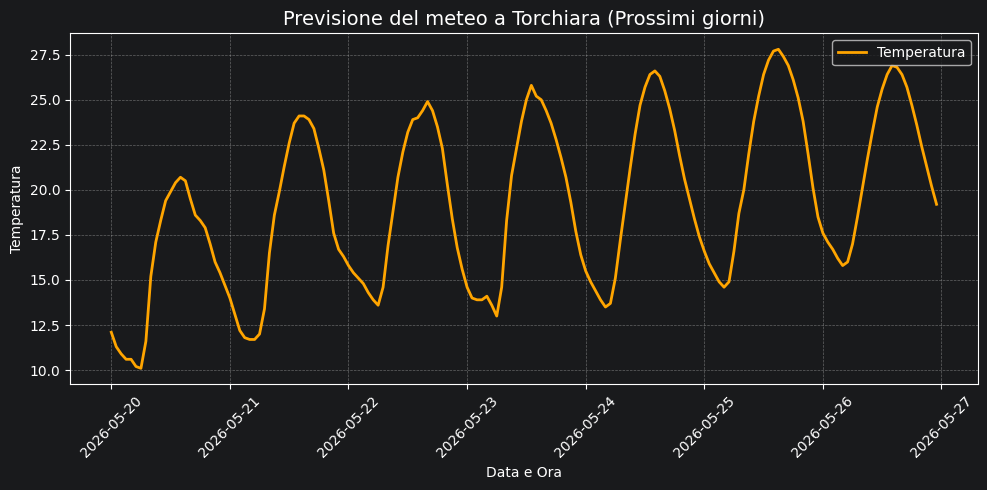

In [30]:
plt.figure(figsize=(10,5))
plt.plot(df['Data_ora'], df['Temperatura °C'], color = 'orange', label = "Temperatura", linewidth = 2)
plt.title(f"Previsione del meteo a Torchiara (Prossimi giorni)", fontsize=14)
plt.xlabel('Data e Ora', fontsize=10)
plt.ylabel('Temperatura', fontsize = 10)
plt.grid(True, linestyle = '--', linewidth = 0.5)

plt.xticks(rotation = 45)
plt.tight_layout()
plt.legend()

plt.show()